In [ ]:
!pip install -Uq pymcel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.0 MB/s eta 0:00:00


In [ ]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

Consultando trayectoria desde 2025-04-08 hasta 2026-04-08...


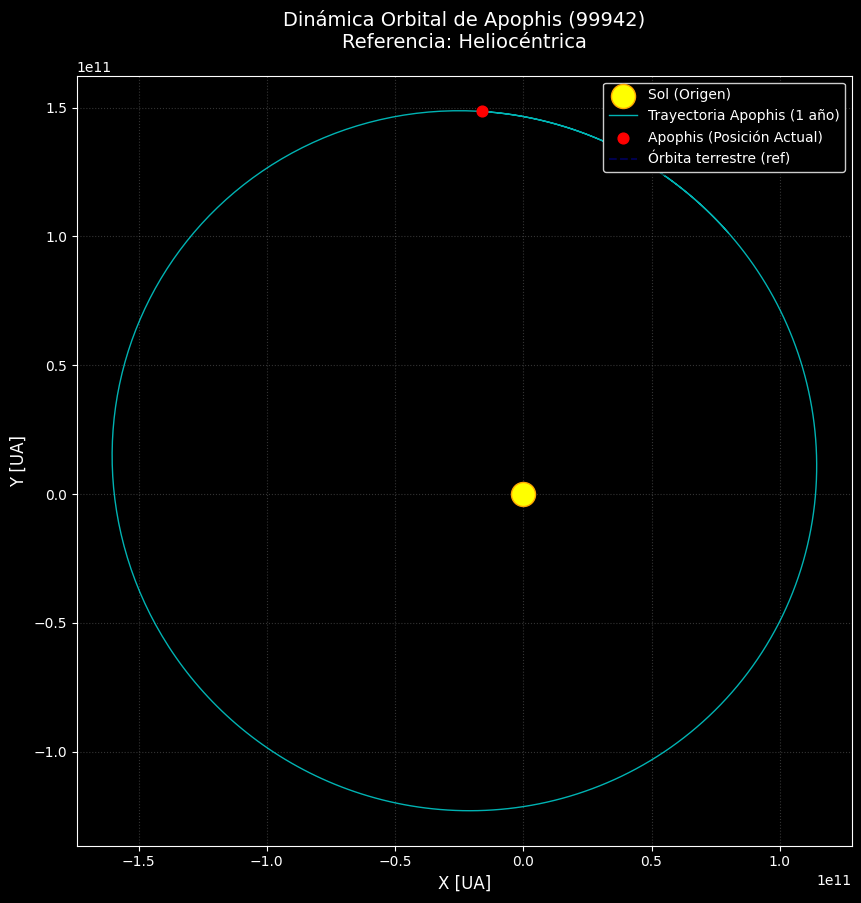

In [ ]:
# 1. Configuración de fechas (Desde hoy hasta un año atrás)
# Usamos la fecha actual del sistema (2026)
fecha_final = datetime.now()
fecha_inicio = fecha_final - timedelta(days=365)

# Formateo de fechas para la consulta a JPL Horizons
start_str = fecha_inicio.strftime('%Y-%m-%d')
stop_str = fecha_final.strftime('%Y-%m-%d')

print(f"Consultando trayectoria desde {start_str} hasta {stop_str}...")

# 2. Consulta a JPL Horizons
# ID de Apophis: 99942
# location='@Sun' pone al Sol en el origen (0,0,0)
tabla, jd, X_raw = pc.consulta_horizons(
    id='99942',
    location='@Sun',
    epochs={'start': start_str, 'stop': stop_str, 'step': '1d'}
)

# 3. CORRECCIÓN DEL ERROR: Convertir a array de NumPy para evitar InvalidIndexError
X_total = np.array(X_raw)

# Extraer posiciones X e Y (están en las primeras dos columnas)
x_apophis = X_total[:, 0]
y_apophis = X_total[:, 1]

# 4. Generación de la gráfica 2D
plt.figure(figsize=(10, 10))
plt.style.use('dark_background') # Fondo espacial

# Dibujar al Sol en el centro
plt.scatter(0, 0, color='yellow', s=300, label='Sol (Origen)', edgecolors='orange', zorder=5)

# Dibujar la "estela" (toda la trayectoria del año)
plt.plot(x_apophis, y_apophis, color='cyan', linestyle='-', linewidth=1, alpha=0.7, label='Trayectoria Apophis (1 año)')

# Dibujar la posición actual de Apophis (el último punto registrado)
plt.scatter(x_apophis[-1], y_apophis[-1], color='red', s=60, label='Apophis (Posición Actual)', zorder=6)

# Añadir la órbita de la Tierra como referencia (Círculo de radio 1 UA aprox.)
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), color='blue', linestyle='--', alpha=0.3, label='Órbita terrestre (ref)')

# Personalización técnica de la gráfica
plt.title(f'Dinámica Orbital de Apophis (99942)\nReferencia: Heliocéntrica', fontsize=14, pad=20)
plt.xlabel('X [UA]', fontsize=12)
plt.ylabel('Y [UA]', fontsize=12)
plt.axis('equal') # Crucial para no deformar la elipse de la órbita
plt.grid(color='gray', linestyle=':', alpha=0.4)
plt.legend(loc='upper right', frameon=True, shadow=True)